In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

✅ Loaded feature_df from ../data/feature_df.csv
   Shape: (26835, 5)
   Features: ['mean_price_usd', 'mean_pct_change', 'volatility', 'mean_deviation', 'spike_count']

🚀 Training Fast SVM (kernel='rbf', C=10, gamma='scale') ...
✅ Training complete!

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4541
           1       0.99      0.92      0.95       826

    accuracy                           0.99      5367
   macro avg       0.99      0.96      0.97      5367
weighted avg       0.99      0.99      0.99      5367

Accuracy: 0.9866


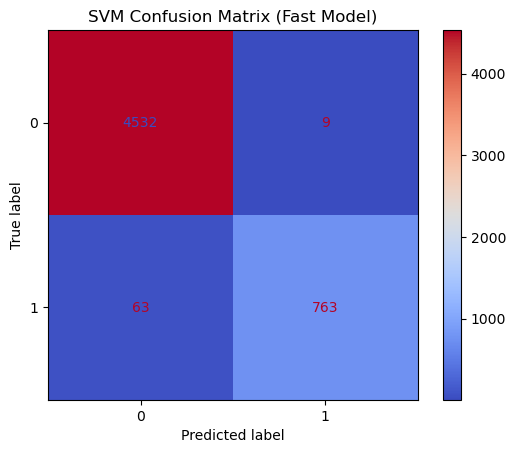

💾 Saved model → ../python_models/models/SVM_models/svm_best_model.pkl
💾 Saved → ../data/report/svm_safe_prices.csv


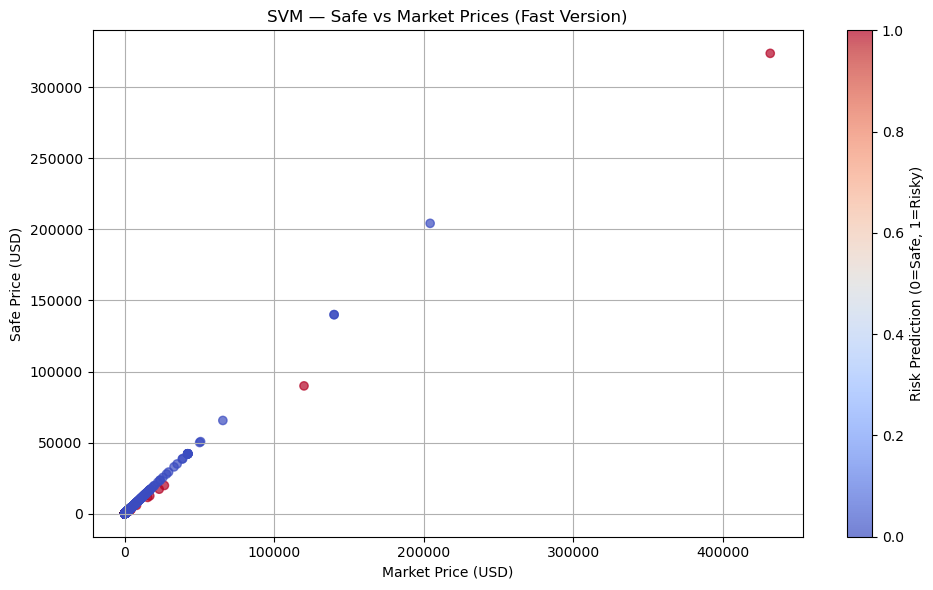

In [2]:


# 1️⃣ Load feature_df from CSV
feature_df_path = "../data/feature_df.csv"
feature_df = pd.read_csv(feature_df_path, index_col=0)
print(f"✅ Loaded feature_df from {feature_df_path}")
print(f"   Shape: {feature_df.shape}")
print(f"   Features: {list(feature_df.columns)}")
print()


# 2️⃣ Ensure risky_label exists

if "risky_label" not in feature_df.columns:
    spike_threshold = feature_df["spike_count"].quantile(0.9)
    vol_threshold   = feature_df["volatility"].quantile(0.9)
    feature_df["risky_label"] = np.where(
        (feature_df["spike_count"] >= spike_threshold) |
        (feature_df["volatility"]   >= vol_threshold),
        1, 0
    )


# 3️⃣ Prepare feature matrix and target

X = feature_df[[
    "mean_price_usd",
    "mean_pct_change",
    "volatility",
    "mean_deviation",
    "spike_count"
]].copy()
y = feature_df["risky_label"].values

# Clean
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = np.clip(X, -1e6, 1e6)
X = np.array(X, dtype=float)

# Split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# 4️⃣ Train Fast SVM (single run, no grid search)

print("🚀 Training Fast SVM (kernel='rbf', C=10, gamma='scale') ...")
svm = SVC(C=10, kernel="rbf", gamma="scale")
svm.fit(x_train_scaled, y_train)
print("✅ Training complete!")


# 5️⃣ Evaluate

y_pred = svm.predict(x_test_scaled)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="coolwarm")
plt.title("SVM Confusion Matrix (Fast Model)")
plt.show()


# 6️⃣ Save Model

os.makedirs("../python_models/models/SVM_models", exist_ok=True)
joblib.dump(svm, "../python_models/models/SVM_models/svm_best_model.pkl")
joblib.dump(scaler, "../python_models/models/SVM_models/svm_scaler.pkl")
print("💾 Saved model → ../python_models/models/SVM_models/svm_best_model.pkl")


# 7️⃣ Predict Risk and Safe Prices

X_scaled = scaler.transform(X)
risk_pred = svm.predict(X_scaled)

feature_df["risk_score_SVM"] = risk_pred
alpha = 0.25
feature_df["safe_price_usd_SVM"] = feature_df["mean_price_usd"] * (1 - alpha * feature_df["risk_score_SVM"])


# 8️⃣ Save Report

os.makedirs("../data/report", exist_ok=True)
svm_report = feature_df[[
    "mean_price_usd", "volatility", "spike_count",
    "risk_score_SVM", "safe_price_usd_SVM"
]].sort_values(by="risk_score_SVM", ascending=False)

svm_report.to_csv("../data/report/svm_safe_prices.csv", index=True)
print("💾 Saved → ../data/report/svm_safe_prices.csv")


# 9️⃣ Visualize Safe vs Market Price

plt.figure(figsize=(10,6))
plt.scatter(svm_report["mean_price_usd"], svm_report["safe_price_usd_SVM"],
            c=svm_report["risk_score_SVM"], cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Risk Prediction (0=Safe, 1=Risky)")
plt.xlabel("Market Price (USD)")
plt.ylabel("Safe Price (USD)")
plt.title("SVM — Safe vs Market Prices (Fast Version)")
plt.grid(True)
plt.tight_layout()
plt.show()  
